In [14]:
import numpy as np

# Set up matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors

%matplotlib inline

from astropy.io import fits

from astropy.utils.data import download_file

image_file = download_file(
    "https://things.cv.nrao.edu/littlethings/ngc2366/HI/NGC2366_R_X0_P_R.FITS", cache=True
)

hdu_list = fits.open(image_file)
hdu_list.info()

image_data = hdu_list[0].data

image_data_2d = np.squeeze(image_data)

Filename: /home/basmala/.astropy/cache/download/url/5c4c2abaefb079d370f9a22ef360e989/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     596   (1024, 1024, 1, 1)   float32   


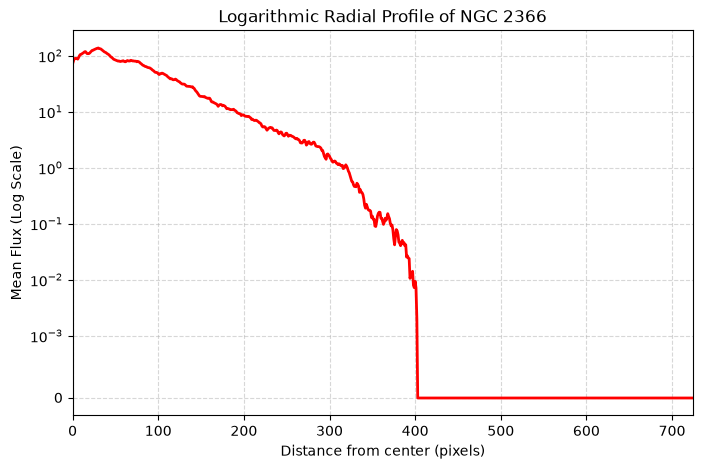

In [15]:
# Create the Radial Profile
y_len, x_len = image_data_2d.shape

center_y, center_x = y_len // 2, x_len // 2

y_indices, x_indices = np.indices((y_len, x_len))

radii = np.sqrt((x_indices - center_x)**2 + (y_indices - center_y)**2)

radii_int = radii.astype(int)

radii_flat = radii_int.flatten()
data_flat = image_data_2d.flatten()

valid_mask = ~np.isnan(data_flat)
radii_valid = radii_flat[valid_mask]
data_valid = data_flat[valid_mask]

bin_sums = np.bincount(radii_valid, weights=data_valid)
bin_counts = np.bincount(radii_valid)

bin_counts[bin_counts == 0] = 1

radial_profile = bin_sums / bin_counts


#Plot the Log
plt.figure(figsize=(8, 5))
plt.plot(radial_profile, color='red', linewidth=2)
plt.yscale('symlog', linthresh=0.001) 
plt.title('Logarithmic Radial Profile of NGC 2366')
plt.xlabel('Distance from center (pixels)')
plt.ylabel('Mean Flux (Log Scale)')
plt.grid(True, which="both", linestyle='--', alpha=0.5) 
plt.xlim(0, max(radii_valid))
plt.show()

In [16]:
radii_safe = np.clip(radii_int, 0, len(radial_profile) - 1)
background_2d = radial_profile[radii_safe]

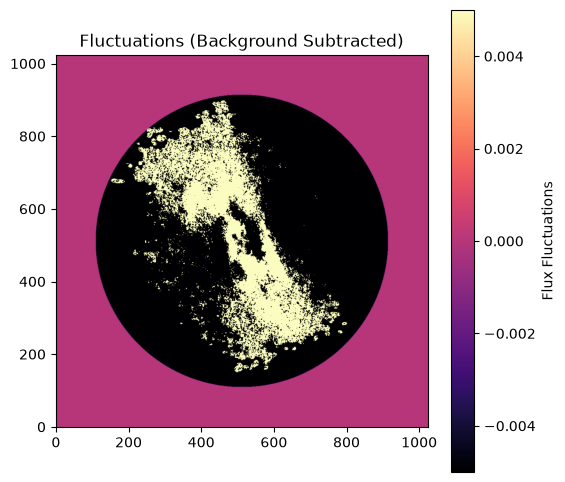

In [17]:
fluctuations = image_data_2d - background_2d
fluctuations[np.isnan(fluctuations)] = 0.0
plt.figure(figsize=(6, 6))
plt.imshow(fluctuations, origin='lower', cmap='magma', vmin=-0.005, vmax=0.005)
plt.title('Fluctuations (Background Subtracted)')
plt.colorbar(label='Flux Fluctuations')
plt.show()

In [18]:
from turbustat.statistics import PowerSpectrum
from astropy.io import fits
import astropy.units as u
np.NaN = np.nan #There's an error because it doesn't recognize np.NaN, so I added this line to fix it.


/home/basmala/miniconda3/envs/BUE/lib/python3.14/site-packages/turbustat/statistics/base_statistic.py:66: UserWarning: Header missing beam information.
  warn("Header missing beam information.")


/home/basmala/miniconda3/envs/BUE/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     2553.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):          2.91e-239
Time:                        23:04:58   Log-Likelihood:                -586.62
No. Observations:                 724   AIC:                             1177.
Df Residuals:                     722   BIC:                             1186.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.5895      0.053     86.003      0.0

/home/basmala/miniconda3/envs/BUE/lib/python3.14/site-packages/turbustat/statistics/elliptical_powerlaw.py:253: RuntimeWarning: divide by zero encountered in log10
  np.log10(x**2 * term1 + x * y * term2 + y**2 * term3)


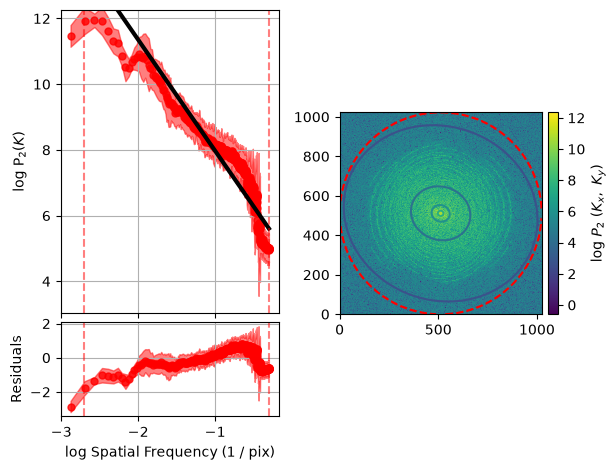

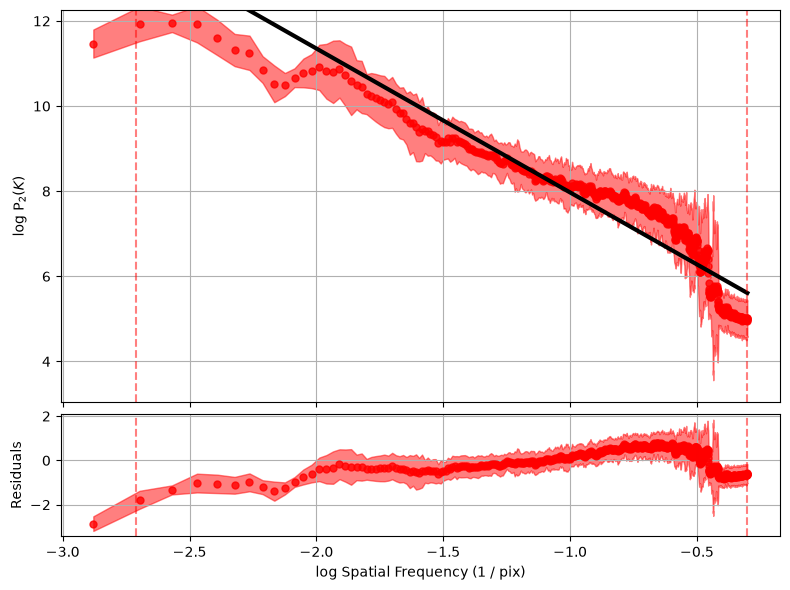

In [19]:
new_hdu = fits.PrimaryHDU(fluctuations)
pspec = PowerSpectrum(new_hdu, distance=250 * u.pc)  
pspec.run(verbose=True, xunit=u.pix**-1) 

# Show the 1D power law fit
plt.figure(figsize=(8,6))
pspec.plot_fit(show_2D=False)
plt.show()

/home/basmala/miniconda3/envs/BUE/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     3127.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):          1.35e-264
Time:                        23:06:08   Log-Likelihood:                -606.69
No. Observations:                 724   AIC:                             1217.
Df Residuals:                     722   BIC:                             1227.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.5110      0.052     87.398      0.0

/home/basmala/miniconda3/envs/BUE/lib/python3.14/site-packages/turbustat/statistics/elliptical_powerlaw.py:253: RuntimeWarning: divide by zero encountered in log10
  np.log10(x**2 * term1 + x * y * term2 + y**2 * term3)


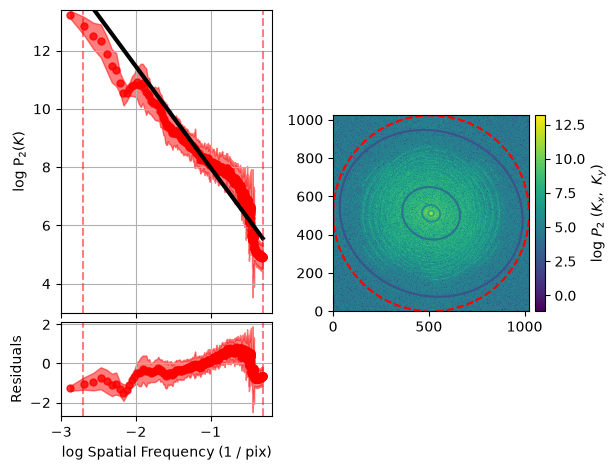

In [20]:

pspec = PowerSpectrum(hdu_list[0], distance=250 * u.pc)  
pspec.run(verbose=True, xunit=u.pix**-1)  

/home/basmala/miniconda3/envs/BUE/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     5969.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):           1.09e-95
Time:                        23:06:12   Log-Likelihood:                 171.55
No. Observations:                 109   AIC:                            -339.1
Df Residuals:                     107   BIC:                            -333.7
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.7617      0.038    152.231      0.0

/home/basmala/miniconda3/envs/BUE/lib/python3.14/site-packages/turbustat/statistics/elliptical_powerlaw.py:253: RuntimeWarning: divide by zero encountered in log10
  np.log10(x**2 * term1 + x * y * term2 + y**2 * term3)


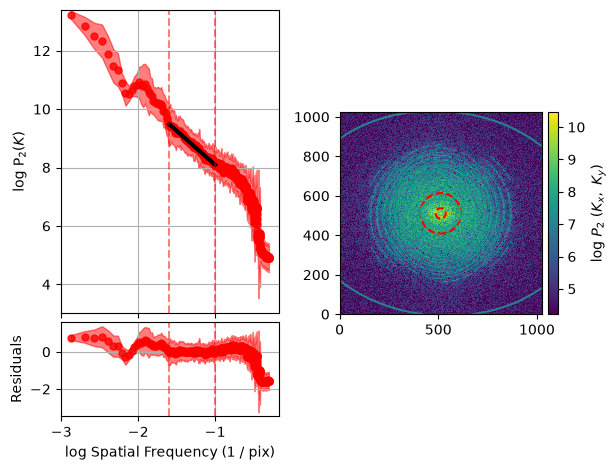

In [21]:
pspec.run(verbose=True, xunit=u.pix**-1, low_cut=0.025 / u.pix,
          high_cut=0.1 / u.pix)  

In [22]:
print(pspec.slope2D, pspec.slope2D_err) 
print(pspec.ellip2D, pspec.ellip2D_err) 
print(pspec.theta2D, pspec.theta2D_err)  

-2.356940793236056 0.023627285935608144
0.7289541160920691 0.007602314848960561
3.0626301252244708 0.014862165766127367


/home/basmala/miniconda3/envs/BUE/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     2403.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):          7.35e-203
Time:                        23:06:14   Log-Likelihood:                -307.95
No. Observations:                 552   AIC:                             619.9
Df Residuals:                     550   BIC:                             628.5
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0059      0.060     83.669      0.0

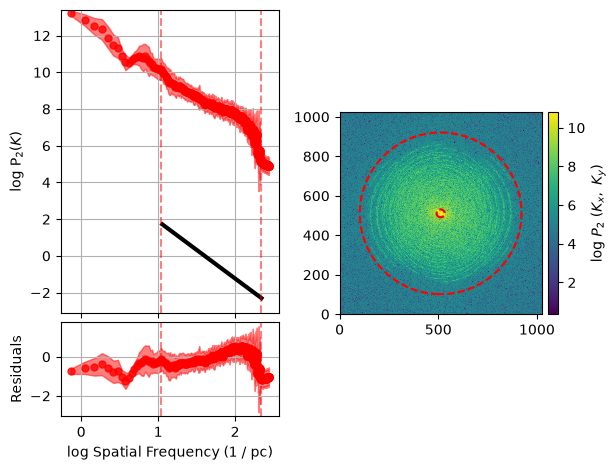

In [23]:
pspec = PowerSpectrum(hdu_list[0], distance=250 * u.pc)  
pspec.run(verbose=True, xunit=u.pc**-1, low_cut=0.02 / u.pix, high_cut=0.4 / u.pix,
          fit_kwargs={ 'log_break': False}, fit_2D=False)  

/home/basmala/miniconda3/envs/BUE/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     1372.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):          1.59e-151
Time:                        23:06:15   Log-Likelihood:                -422.83
No. Observations:                 552   AIC:                             849.7
Df Residuals:                     550   BIC:                             858.3
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6756      0.075     62.666      0.0

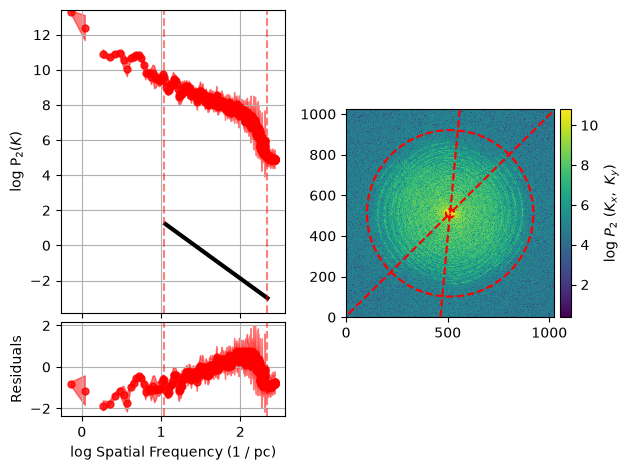

In [24]:
pspec = PowerSpectrum(hdu_list[0], distance=250 * u.pc)  
pspec.run(verbose=True, xunit=u.pc**-1, low_cut=0.02 / u.pix, high_cut=0.4 / u.pix,
          fit_2D=False, fit_kwargs={'log_break': False}, #'brk': 0.1 / u.pix,
          radial_pspec_kwargs={"theta_0": 1.13 * u.rad, "delta_theta": 40 * u.deg})  

/home/basmala/miniconda3/envs/BUE/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.981
Model:                            WLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     5323.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):           4.47e-93
Time:                        23:06:20   Log-Likelihood:                 169.17
No. Observations:                 109   AIC:                            -334.3
Df Residuals:                     107   BIC:                            -329.0
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.7546      0.040    143.495      0.0

/home/basmala/miniconda3/envs/BUE/lib/python3.14/site-packages/turbustat/statistics/elliptical_powerlaw.py:253: RuntimeWarning: divide by zero encountered in log10
  np.log10(x**2 * term1 + x * y * term2 + y**2 * term3)


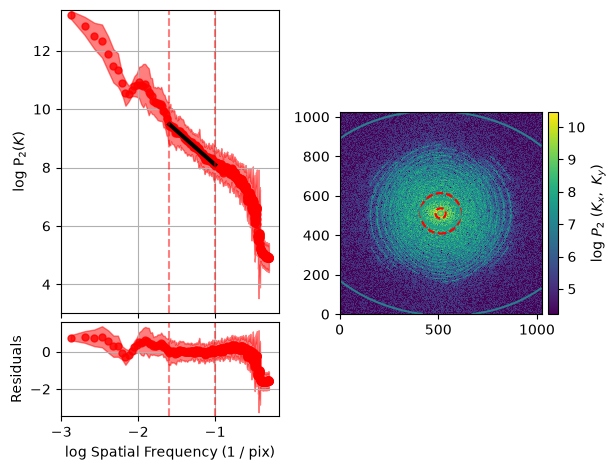

In [25]:
pspec = PowerSpectrum(hdu_list[0], distance=250 * u.pc)  
pspec.run(verbose=True, xunit=u.pix**-1, low_cut=0.025 / u.pix, high_cut=0.1 / u.pix,
          fit_kwargs={'weighted_fit': True})  

FIRE, PHANGS -> galaxy
SKAO, EUCLID, DESI, BAO -> cosmology